1. Import Libraries

Import core libraries required for data handling (pandas, numpy) and visualization (matplotlib).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Basic Data Audit
This cell checks dataset shape, column names, data types, missing values, and target balance.

In [ ]:
df = pd.read_csv("../train.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,641,53,Male,Switzerland,non-anginal,160.0,0.0,NaN,lv hypertrophy,122.0,True,0.0,NaN,NaN,reversable defect,1
1,744,74,Male,VA Long Beach,non-anginal,NaN,0.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,0
2,891,53,Male,VA Long Beach,asymptomatic,124.0,243.0,False,normal,122.0,True,2.0,flat,NaN,reversable defect,1
3,271,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect,1
4,655,56,Male,Switzerland,non-anginal,155.0,0.0,False,st-t abnormality,99.0,False,0.0,flat,NaN,normal,1


3. Basic Data Audit
Inspect dataset structure: shape, column names, data types, missing values, and target distribution to assess class imbalance.

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget counts:")
print(df["target"].value_counts())

print("\nTarget proportions:")
print(df["target"].value_counts(normalize=True))

Shape: (736, 16)

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
target        int64
dtype: object

Missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     50
chol         27
fbs          68
restecg       0
thalch       47
exang        47
oldpeak      52
slope       241
ca          485
thal        381
target        0
dtype: int64

Target counts:
target
1    407
0    329
Name: count, dtype: int64

Target proportions:
target
1    0.552989
0    0.447011
Name: proportion, dtype: float64


4. Target Distribution Visualization
Visualize the distribution of the target variable (heart disease vs no disease) to support evaluation metric selection.

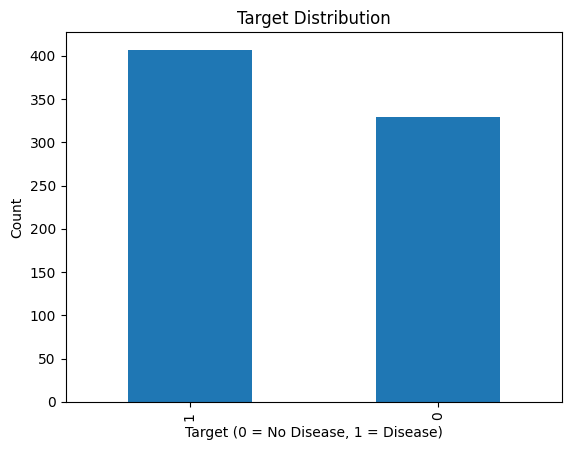

In [ ]:
df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()

5. Institutional (Dataset) Analysis
Analyze distribution of patients and disease prevalence across contributing hospitals using the dataset column

dataset
Cleveland        249
Hungary          229
VA Long Beach    163
Switzerland       95
Name: count, dtype: int64
target           0    1
dataset                
Cleveland      136  113
Hungary        145   84
Switzerland      7   88
VA Long Beach   41  122


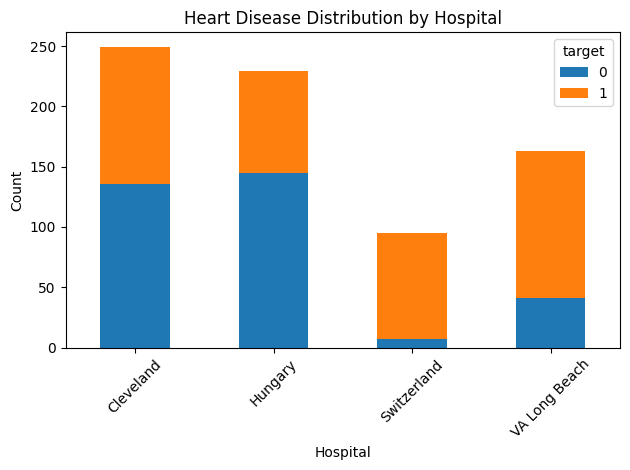

In [ ]:
print(df["dataset"].value_counts())

site_target = pd.crosstab(df["dataset"], df["target"])
print(site_target)

site_target.plot(kind="bar", stacked=True)
plt.title("Heart Disease Distribution by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6. Data Quality Check (Invalid Values)
Identify biologically implausible values (e.g., cholesterol = 0) which indicate missing or corrupted data.

In [ ]:
print("chol == 0:", (df["chol"] == 0).sum())
print("trestbps == 0:", (df["trestbps"] == 0).sum())

if "thalch" in df.columns:
    print("thalch == 0:", (df["thalch"] == 0).sum())

chol == 0: 132
trestbps == 0: 0
thalch == 0: 0


7. Replace Invalid Values
Convert invalid placeholder values (e.g., zeros) into proper missing values (NaN) for correct downstream handling.

In [ ]:
df["chol"] = df["chol"].replace(0, np.nan)
df["trestbps"] = df["trestbps"].replace(0, np.nan)

if "thalch" in df.columns:
    df["thalch"] = df["thalch"].replace(0, np.nan)

8. Feature Type Identification
Separate numerical and categorical features and exclude non-predictive columns (id, target) from preprocessing groups.

In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "string", "bool"]).columns.tolist()

for col in ["id", "target"]:
    if col in num_cols:
        num_cols.remove(col)
    if col in cat_cols:
        cat_cols.remove(col)

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


9. Missing Value Imputation
Fill missing values using:

Median for numerical features
Mode for categorical features Ensure no missing values remain in modelling features.

In [ ]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


10. Remove Identifier Column
Drop the id column to prevent data leakage, as it does not carry predictive clinical information.

In [ ]:
if "id" in df.columns:
    df = df.drop(columns=["id"])

print("id still present?", "id" in df.columns)

id still present? False


11. Categorical Feature Encoding
Convert categorical variables into numerical format using one-hot encoding to make them usable by machine learning models.

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True,
    prefix_sep="_"
)

print("Encoded shape:", df_encoded.shape)
df_encoded.head()

Encoded shape: (736, 22)


,age,trestbps,chol,thalch,oldpeak,ca,target,sex_Male,dataset_Hungary,dataset_Switzerland,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,53,160.0,239.0,122.0,0.0,0.0,1,True,False,True,...,True,False,False,False,False,True,True,False,False,True
1,74,130.0,239.0,140.0,0.5,0.0,0,True,False,False,...,True,False,False,True,False,False,True,False,True,False
2,53,124.0,243.0,122.0,2.0,0.0,1,True,False,False,...,False,False,False,True,False,True,True,False,False,True
3,61,140.0,207.0,138.0,1.9,1.0,1,True,False,False,...,False,False,False,False,False,True,False,True,False,True
4,56,155.0,239.0,99.0,0.0,0.0,1,True,False,True,...,True,False,False,False,True,False,True,False,True,False


12. Final Dataset Preparation
Verify no remaining missing values and split the dataset into:

Features (X)
Target variable (y) Ready for model training.

In [ ]:
print("Remaining missing values after preprocessing:")
print(df_encoded.isnull().sum().sum())

X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

Remaining missing values after preprocessing:
0
X shape: (736, 21)
y shape: (736,)


3.  Modelling and Analysis
#Issue 7 - Feature Analysis and Selection
identify features strongly related to target
identify which features are highly correlated with each other
identify features with almost no relationship to the target

Correlation Heatmap

<function matplotlib.pyplot.show(close=None, block=None)>

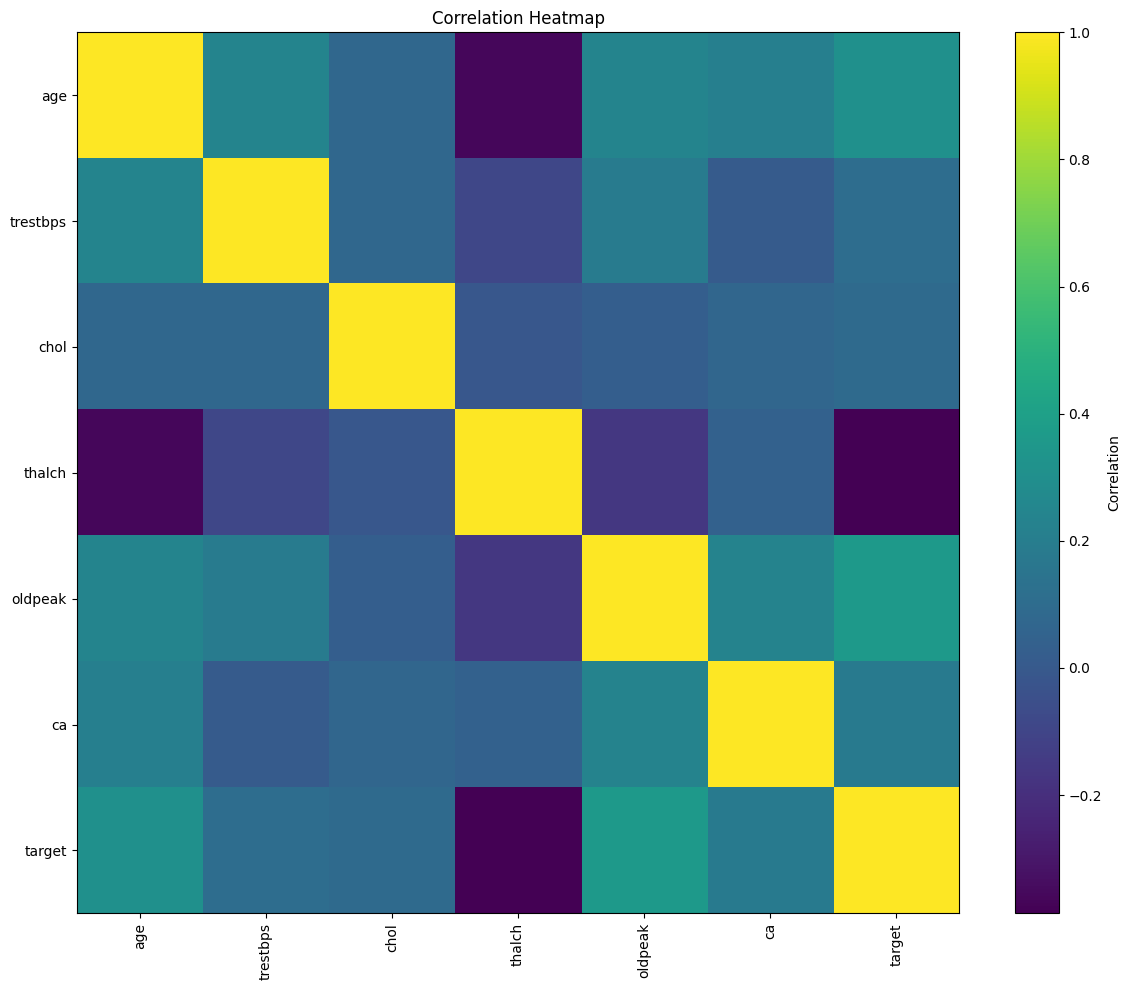

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# use the cleaned dataframe after preprocessing 

corr = df.drop(columns=["id"],errors="ignore").corr(numeric_only=True)

plt.figure(figsize=(12,10))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show

In [ ]:
corr_target = corr['target'].sort_values(ascending=False)
print(corr_target)

target      1.000000
oldpeak     0.363600
age         0.309624
ca          0.179599
trestbps    0.111842
chol        0.091035
thalch     -0.385915
Name: target, dtype: float64


Summary Table

In [ ]:
feature_corr_summary = pd.DataFrame({
    'Feature': ["oldpeak", "age", "ca", "trestbps", "chol", "thalch"],
    'Correlation_with_Target': [0.363600, 0.309624, 0.179599, 0.111842, 0.091035, -0.385915]
})
feature_corr_summary["Abs_Correlation"] = feature_corr_summary["Correlation_with_Target"].abs()

feature_corr_summary = feature_corr_summary.sort_values(
    by="Abs_Correlation",
    ascending=False
)
    
feature_corr_summary

,Feature,Correlation_with_Target,Abs_Correlation
5,thalch,-0.385915,0.385915
0,oldpeak,0.363600,0.363600
1,age,0.309624,0.309624
2,ca,0.179599,0.179599
3,trestbps,0.111842,0.111842
4,chol,0.091035,0.091035


The strongest relationship with heart disease is observed for thalch and oldpeak.  thalch showed a moderate negative correlation, and this shows that patients with lower maximum heart rate are likely to have heart disease. old peak showed a moderate positive correlation and this shows that greater ST depression is associated with increased heart disease risk.  Age has a positive relations.  In contrast trestbps and chol had a weak correlation with the target, and may be not meaningful as standalone predictors but may be useful in combinations with other variables.

Random Forest for Feature importance

to capture non-linear relationships

In [ ]:
X = df.drop(columns=["target", "id"], errors="ignore")
y = df["target"]

X_encoded = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42    
)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
print("Random Forest trained Successfully")

Random Forest trained Successfully


In [ ]:
importance_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
importance_df.head(10)

,Feature,Importance
0,age,0.125133
3,thalch,0.125077
4,oldpeak,0.112616
2,chol,0.100548
16,exang_True,0.089686
1,trestbps,0.067761
10,cp_atypical angina,0.054758
6,sex_Male,0.042748
8,dataset_Switzerland,0.037108
11,cp_non-anginal,0.032458


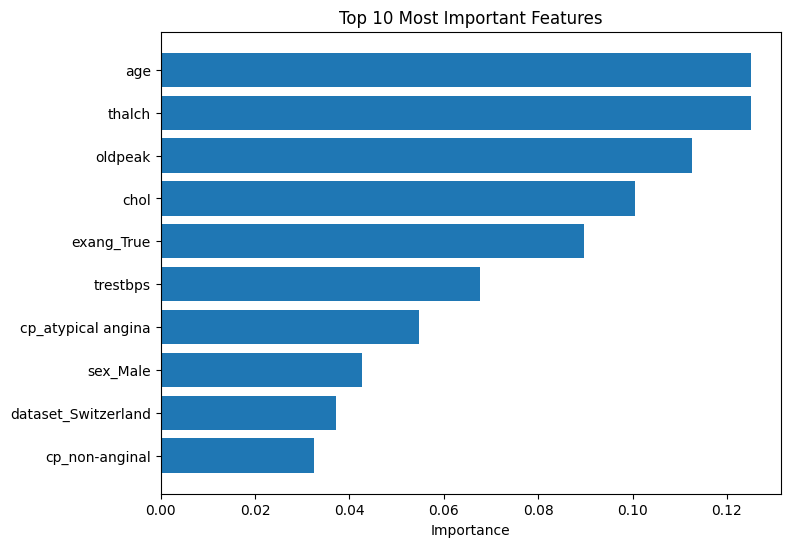

In [ ]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(8,6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 10 Most Important Features")
plt.tight_layout
plt.show()

In [ ]:
decision_table = pd.DataFrame({
    "Feature": ["age", "thalch", "oldpeak", "chol", "trestbps", "ca"],
    "Correlation_with_Target": [0.309624, -0.385915, 0.363600, 0.091035, 0.1111842, 0.179599],
    "RF_Importance": [0.125133, 0.125077, 0.112616, 0.100548, 0.06776, None],
    "Decision": [
        "Keep",
        "Keep",
        "Keep",
        "Keep",
        "Keep",
        "Keep",
        ],
    "Reason": [
        "Moderate positive correlation and higheest RF importance",
        "Strongest negative correlation and highest RF imporatnce",
        "Strongest positive correlation and high RF importance",
        "Weak correlation but important in RF, suggesting interactions",
        "Weak correlation but some predictive value in RF",
        "Moderate correlation; retained pending further testing"
    ]
})

decision_table

,Feature,Correlation_with_Target,RF_Importance,Decision,Reason
0,age,0.309624,0.125133,Keep,Moderate positive correlation and higheest RF ...
1,thalch,-0.385915,0.125077,Keep,Strongest negative correlation and highest RF ...
2,oldpeak,0.363600,0.112616,Keep,Strongest positive correlation and high RF imp...
3,chol,0.091035,0.100548,Keep,"Weak correlation but important in RF, suggesti..."
4,trestbps,0.111184,0.067760,Keep,Weak correlation but some predictive value in RF
5,ca,0.179599,NaN,Keep,Moderate correlation; retained pending further...


The Random Forest identified age, thalch, oldpeak and chol as the most important predictors of heart disease.  Exercise induced aginag and chest pain atypical angina aslo contributed substantially.  Although cholestrol and resting blood pressure showed weak correlations with the target, they show signficant import in the Random Forest model, and this suggests that they interact with other clinical variables.  Therefore, all features will be retained for subsequest modelling.

Issue 7 Summary

1. Generated a correlation heatmap for the cleaned dataset.
2. Calculated the correlation of each feature with the target.
3. Identified the strongest predictors (thalch, oldpeak, age).
4. Created a summary table ranking features of absolute correlation.
5. Trained a scikit-learn Random Forest model for feature importance analysis.
6. Extracted and ranked Random Forest Feature importances.
7. Identified the top contributing variables (age, thalch, oldpeak, chol, exang_True).
8. Created a decision table combining correlation, feature imporatance and keep/remove recommendations.
9. Concluded that no features should be removed at this stage and all variables will be retained for later modeling.